In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [290]:
data_file = pd.read_csv('glass.txt', delimiter=r'\s+')
data = data_file[['RI', 'Al']]

data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)

x_data = data['Al'].values
y_data = data['RI'].values

In [291]:
class UniformKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.x_data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.x_data = x_data
        self.y_data = y_data

    def __uniform_kernel(self, x):
        """Uniform kernel function."""
        return np.where(np.abs(x) <= 0.5, 1, 0)

    def kernel(self, x, xi):
        """Applies the uniform kernel to the data."""
        if(self.bandwidth == 0):
            return 0
        
        else:
            return self.__uniform_kernel((x - xi) / self.bandwidth)    
        
        


    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.kernel(point, self.x_data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)

In [292]:


def k_fold_error(func, x_input, y_input, best_bandwidth):
    
    data_length = int(len(x_data)/10)
    risk = 0
    for i in range(10):
        x_input = np.concatenate([x_data[:i*data_length], x_data[(i+1)*data_length:]])
        y_input = np.concatenate([y_data[:i*data_length], y_data[(i+1)*data_length:]])
        
        x_output = x_data[i*data_length:(i+1)*data_length]
        y_expected = y_data[i*data_length:(i+1)*data_length]
        
        kde = func(bandwidth=best_bandwidth * 20)
        kde.fit(x_input, y_input)
        y_output = kde.predict(x_output)
        
        risk = risk + np.mean((y_output - y_expected) ** 2)
    
    risk = risk / 10
    return risk

    
        

In [293]:
bandwidths_Ukde = np.linspace(0.01, 1, 1000)

# bandwidths_Ukde = bandwidths_Ukde[1:]

risks_Ukde = []
for bandwidth in bandwidths_Ukde:
    
    risk = k_fold_error(UniformKDE, x_data, y_data, bandwidth)
    # print(risk)
    risks_Ukde.append(risk)
    
    # print(bandwidth)



    
# print(risks_Ukde)
# print(bandwidths_Ukde)

best_bandwidth_Ukde = bandwidths_Ukde[np.argmin(risks_Ukde)]
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Ukde}")

bandwidth corresponding to minimum estimated risk is 0.0318018018018018


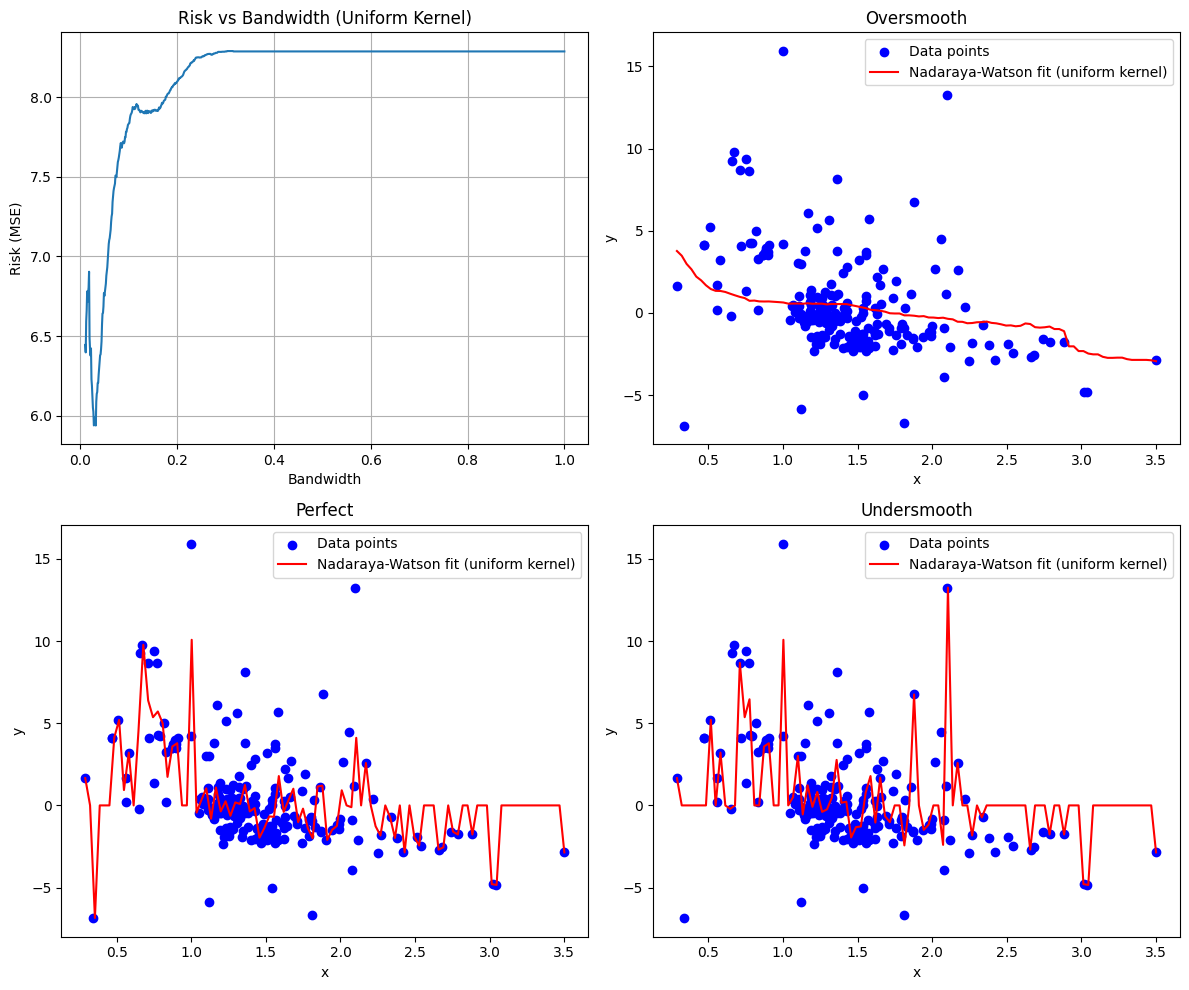

<Figure size 640x480 with 0 Axes>

In [294]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_Ukde, risks_Ukde)
# print(risks_Ukde)
# axs[0, 0].set_xlim([0, 1])
# axs[0, 0].set_ylim([4, 10])
axs[0, 0].set_title('Risk vs Bandwidth (Uniform Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = UniformKDE(bandwidth=best_bandwidth_Ukde * 50)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = UniformKDE(bandwidth=best_bandwidth_Ukde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = UniformKDE(bandwidth=best_bandwidth_Ukde / 2)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()


plt.tight_layout()
plt.show()

plt.savefig("uniform_kernel_regression.png")

In [295]:
class EpanechnikovKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.x_data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.x_data = x_data
        self.y_data = y_data

    def __epanechnikov(self, x):
        # mod_x_squared=np.sum(x**2, axis=-1)
        # print(0, 0.75*(1-x**2))
        return np.maximum(0, 0.75*(1-x**2))
    
    

    def epanechnikov_kernel(self, x, xi):
        """Epanechnikov kernel function."""
        if(self.bandwidth == 0):
            return 0
        
        else:
            return self.__epanechnikov((x-xi) / self.bandwidth)
        
        

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.epanechnikov_kernel(point, self.x_data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)
    

In [296]:
bandwidths_Ekde = np.linspace(0.01, 1, 1000)
risks_Ekde = []
for bandwidth in bandwidths_Ekde:
    
    risk = k_fold_error(UniformKDE, x_data, y_data, bandwidth)
    # print(risk)
    risks_Ekde.append(risk)
    
    # print(bandwidth)

    
# print(risks_Ekde)
# print(bandwidths_Ekde)

best_bandwidth_Ekde = bandwidths_Ekde[np.argmin(risks_Ekde)]
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Ekde}")

bandwidth corresponding to minimum estimated risk is 0.0318018018018018


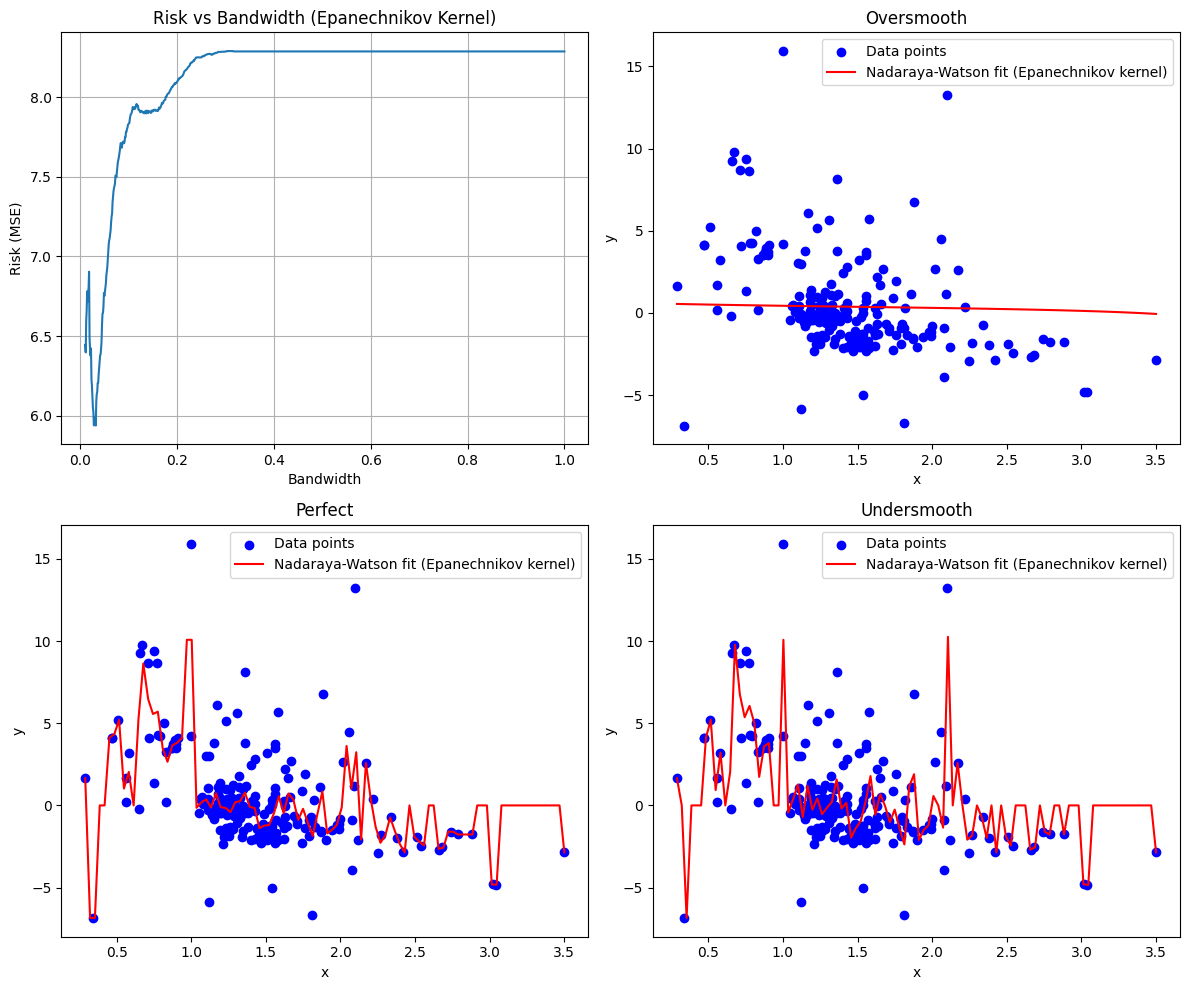

<Figure size 640x480 with 0 Axes>

In [297]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_Ekde, risks_Ekde)
axs[0, 0].set_title('Risk vs Bandwidth (Epanechnikov Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 100)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 2)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

plt.savefig("epanechnikov_kernel_regression.png")

In [298]:
# plt.savefig("epanechnikov_kernel_regression.png")

In [299]:
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Ekde}")

bandwidth corresponding to minimum estimated risk is 0.0318018018018018


1. Can you empirically corroborate above statement using plots ? Are all kernel functions similarly dependent on choice of optimal bandwidth ?



Comparing plots of each function

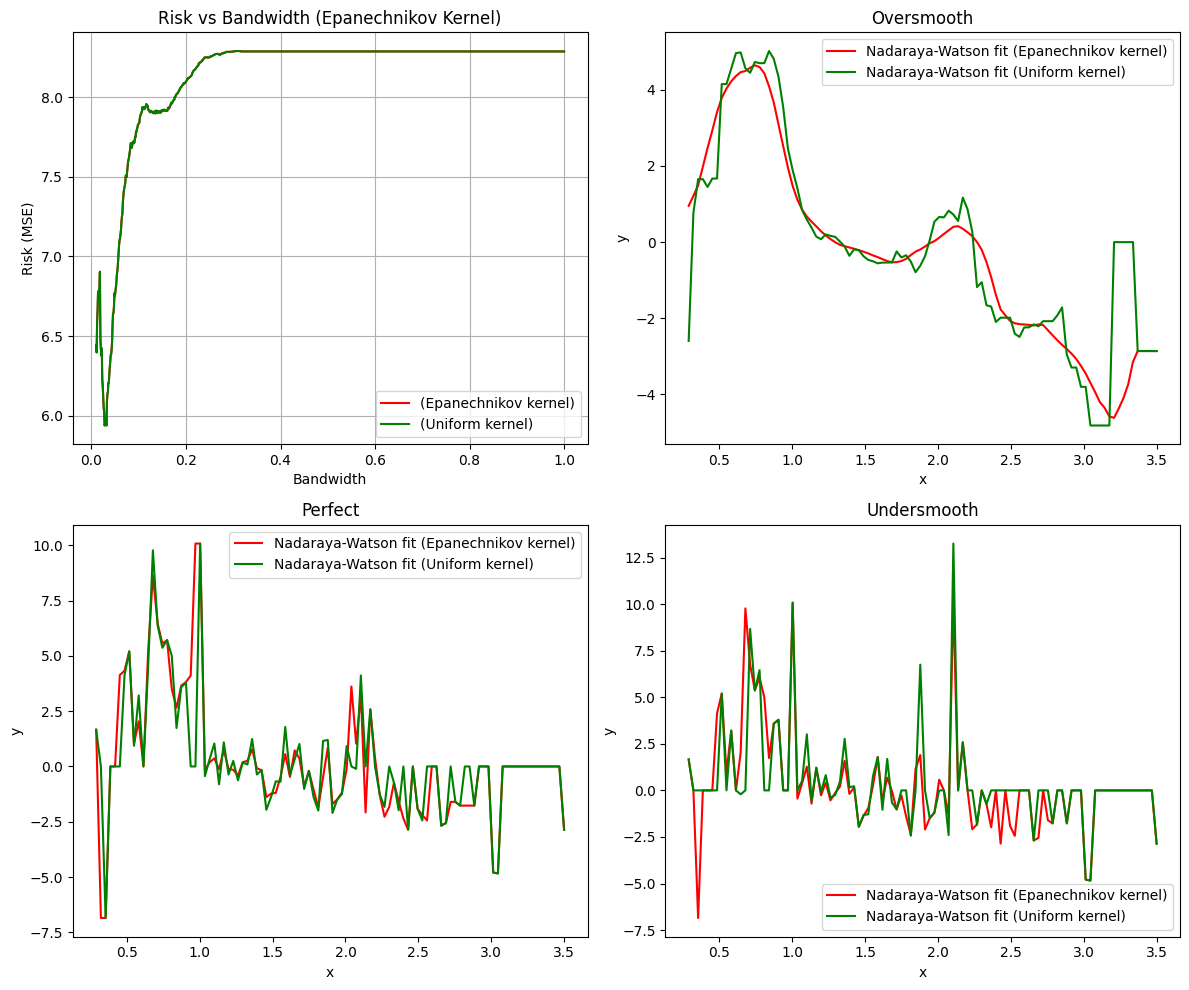

In [300]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_Ukde, risks_Ukde, color='red', label='(Epanechnikov kernel)')
axs[0, 0].plot(bandwidths_Ekde, risks_Ekde, color='green', label='(Uniform kernel)')
axs[0, 0].set_title('Risk vs Bandwidth (Epanechnikov Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)
axs[0, 0].legend()

# Oversmooth
Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 10)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde * 10)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

# axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fitE, y_fitE, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].plot(x_fitU, y_fitU, color='green', label='Nadaraya-Watson fit (Uniform kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde )
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

# axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fitE, y_fitE, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].plot(x_fitU, y_fitU, color='green', label='Nadaraya-Watson fit (Uniform kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 2)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde / 2)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

# axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fitE, y_fitE, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].plot(x_fitU, y_fitU, color='green', label='Nadaraya-Watson fit (Uniform kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

## Is optimal bandwidth dependent on choice of kernel ?

In [301]:
best_bandwidth_Ekde

0.0318018018018018

In [302]:
best_bandwidth_Ukde

0.0318018018018018

In [303]:
best_bandwidth_Ukde - best_bandwidth_Ekde

0.0

Well, as we can see it is independent of the kernel being used. #Reason?

## K-fold Cross-validation


In [304]:
# data = data_file[['RI', 'Al']]

#reimplementation
data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)

x_data = data['RI'].values
y_data = data['Al'].values

def k_fold_error_new(func, best_bandwidth):
    
    data_length = int(len(x_data)/10)
    error = 0
    for i in range(10):
        x_input = np.concatenate([x_data[:i*data_length], x_data[(i+1)*data_length:]])
        y_input = np.concatenate([y_data[:i*data_length], y_data[(i+1)*data_length:]])
        
        x_output = x_data[i*data_length:(i+1)*data_length]
        y_expected = y_data[i*data_length:(i+1)*data_length]
        
        kde = func(bandwidth=best_bandwidth * 20)
        kde.fit(x_input, y_input)
        y_output = kde.predict(x_output)
        
        error = error + np.sum((y_output - y_expected) ** 2)
    
    error = error / 10
    return error
    
    
        

In [305]:
UniformKDE_k_fold_error = k_fold_error_new(UniformKDE, best_bandwidth_Ukde)
UniformKDE_k_fold_error

5.173245078002173

In [306]:
EpanechnikovKDE_k_fold_error = k_fold_error_new(EpanechnikovKDE, best_bandwidth_Ekde)
EpanechnikovKDE_k_fold_error

5.0474149515830415

## Which is better by what margin ?


In [307]:
print(UniformKDE_k_fold_error - EpanechnikovKDE_k_fold_error)

0.12583012641913172


In [308]:
diff = ((UniformKDE_k_fold_error - EpanechnikovKDE_k_fold_error)*100/EpanechnikovKDE_k_fold_error)
if diff > 0:
    print(f"Uniform KDE has {diff:.2f}% more error than Epanechnikov KDE.")
else:
    print(f"Uniform KDE has {abs(diff):.2f}% less error than Epanechnikov KDE.")


Uniform KDE has 2.49% more error than Epanechnikov KDE.


In [309]:
diff = ((EpanechnikovKDE_k_fold_error - UniformKDE_k_fold_error)*100/UniformKDE_k_fold_error)

if diff > 0:
    print(f"Epanechnikov KDE has {diff:.2f}% more error than Uniform KDE.")
else:
    print(f"Epanechnikov KDE has {abs(diff):.2f}% less error than Uniform KDE.")

Epanechnikov KDE has 2.43% less error than Uniform KDE.
